In [30]:
#upload csv

import pandas as pd
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt


df = pd.read_csv('data/cleaned/all_sessions_keywords_filtered.csv')
df

,session,date,month,day,year,title,keywords,kw_1,kw_2,kw_3,kw_4,kw_5,kw_6,kw_7,kw_8,kw_9,kw_10
0,119.0,"July 29, 2025",7.0,29,2025,PERSPECTIVES ON REAUTHORIZATION OF THE U.S. G...,agriculture nutrition; reauthorization; forest...,agriculture nutrition,reauthorization,forests act,farm bureau,grain,Tribal Programs,USDA,nutrition forestry,american farmers,regulatory
1,119.0,"July 23, 2025",7.0,23,2025,NOMINATION OF RICHARD FORDYCE TO BE UNDER SEC...,secretary agriculture; mr fordyce; farm bureau...,secretary agriculture,mr fordyce,farm bureau,nutrition forestry,washington 2025,conservation programs,nomination,USDA,agriculture nutrition,north dakota
2,119.0,"July 15, 2025",7.0,15,2025,STAKEHOLDER PERSPECTIVES ON FEDERAL OVERSIGHT...,farm bureau; tariffs; stakeholders; nutrition ...,farm bureau,tariffs,stakeholders,nutrition forestry,fed,advance appropriations,regulatory,Tribal Programs,commerce science,government accountability
3,119.0,"June 10, 2025",6.0,10,2025,"NOMINATION OF THE HONORABLE BRIAN QUINTENZ, T...",secretary agriculture; bie funded; Tribal Prog...,secretary agriculture,bie funded,Tribal Programs,2025 statements,roger wicker,Natural Gas,nomination,farm bureau,usda,futures
4,119.0,"June 3, 2025",6.0,3,2025,NOMINATION OF MICHAEL BOREN TO BE UNDER SECRET...,secretary agriculture; nutrition forestry; bor...,secretary agriculture,nutrition forestry,boren,farm bureau,adam schiff,Natural Gas,nomination,Tribal Programs,south dakota,agriculture nutrition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,118.0,"March 22, 2023",3.0,22,2023,STRENGTHENING METHODS OF RECRUITMENT AND RETEN...,recruitment; Veterans Affairs; tenure; veteran...,recruitment,Veterans Affairs,tenure,veterans,care workforce,draft,reauthorization,partisan,Veterans Affairs,questions submitted
672,118.0,"March 15, 2023",3.0,15,2023,EXAMINING THE FUTURE PATH OF VA'S ELECTRONIC H...,Veterans Affairs; questions record; Health Pla...,Veterans Affairs,questions record,Health Plans,CDC,forward hearing,filed,Veterans Affairs,journal,year 2023,legislative
673,118.0,"March 8, 2023",3.0,8,2023,LEGISLATIVE PRESENTATION OF VETERANS OF FOREI...,Veterans Affairs; documentation; legislative; ...,Veterans Affairs,documentation,legislative,veterans,defense authorization,doi org,questions record,whitehouse thank,tax code,navajo nation
674,118.0,"March 1, 2023",3.0,1,2023,LEGISLATIVE PRESENTATION OF THE,Veterans Affairs; legislative; doi org; pursua...,Veterans Affairs,legislative,doi org,pursuant notice,filed,hrsa,veterans,navajo nation,presiding present,defense authorization


In [31]:
# list of most common keywords using kw1-kw10 columns (cleaned)
from collections import Counter

# Mirror banned list used in test_keyburt.ipynb
banned_substrings = [
    'senate committee', 'house committee', 'committee hearing', 'hearing committee',
    'committee judiciary', 'committee finance', 'finance committee', 'committee health',
    'committee presiding', 'special committee', 'members subcommittee', 'members senate',
    'committee aging', 'use committee', 'committee thank', 'committees',
    'committee met', 'members committee', 'members congress', 'subcommittee',
    'opening statement', 'testimony', 'chairman', 'ranking member', 'senator',
    'representative', 'congressman', 'congresswoman', 'good morning', 'good afternoon',
    'thank you', 'distinguished', 'witness', 'panel', 'hearing adjourned', 'hearing today',
    'senate', 'states senate', 'congress session', 'eighteenth congress', 'congress',
    '2023 senate', '2024 budget', 'senate office', 'senate eighteenth', 'hearings',
    'congressional', 'pdf washington', 'dc committee', 'act 2023', 'gov document',
    'republican staff', 'chair warren', 'document fcc', 'filing',
]

normalize_map = {
    'president budget': "president's budget",
    "president's budget": "president's budget",
    'presidents budget': "president's budget",
    'white house budget': "president's budget",
    'epa': 'EPA', 'fcc': 'FCC', 'federal reserve': 'Federal Reserve',
    'veterans affairs': 'Veterans Affairs', 'va': 'Veterans Affairs',
    'department of energy': 'DOE', 'doe': 'DOE',
    'department of transportation': 'DOT', 'dot': 'DOT',
    'department of defense': 'DoD', 'dod': 'DoD',
    'department of homeland security': 'Homeland Security', 'dhs': 'Homeland Security',
    'centers for disease control': 'CDC', 'cdc': 'CDC',
    'food and drug administration': 'FDA', 'fda': 'FDA',
    'bipartisan infrastructure': 'Bipartisan Infrastructure',
    'bipartisan support': 'Bipartisan Support',
    'federal funding': 'Federal Funding', 'federal agencies': 'Federal Agencies',
    'natural gas': 'Natural Gas', 'health plans': 'Health Plans',
    'tax cuts': 'Tax Cuts', 'tribal programs': 'Tribal Programs',
}


def is_banned(k: str) -> bool:
    kl = k.lower()
    if kl.strip() == '':
        return True
    for sub in banned_substrings:
        if sub in kl:
            return True
    return False


def norm(k: str) -> str:
    kl = k.lower()
    return normalize_map.get(kl, k)

all_keywords = []
for i in range(1, 11):
    col = f'kw_{i}'
    if col in df.columns:
        cleaned = [norm(x) for x in df[col].dropna().tolist() if not is_banned(x)]
        cleaned = [x for x in cleaned if isinstance(x, str) and x.strip() != '']
        all_keywords.extend(cleaned)

keyword_counts = Counter(all_keywords)
most_common_keywords = keyword_counts.most_common(20)
most_common_keywords

[('executive branch', 148),
 ("president's budget", 144),
 ('partisan', 114),
 ('Veterans Affairs', 100),
 ('Tax Cuts', 94),
 ('EPA', 93),
 ('additional funding', 79),
 ('trade commission', 64),
 ('executive order', 64),
 ('homeland security', 63),
 ('appropriations', 61),
 ('USDA', 55),
 ('biden administration', 55),
 ('tariffs', 54),
 ('department energy', 54),
 ('forward hearing', 54),
 ('Tribal Programs', 51),
 ('www govinfo', 49),
 ('defense authorization', 47),
 ('2023 __________', 47)]

c:\Users\Maste\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\Maste\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\Maste\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\Maste\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*ar

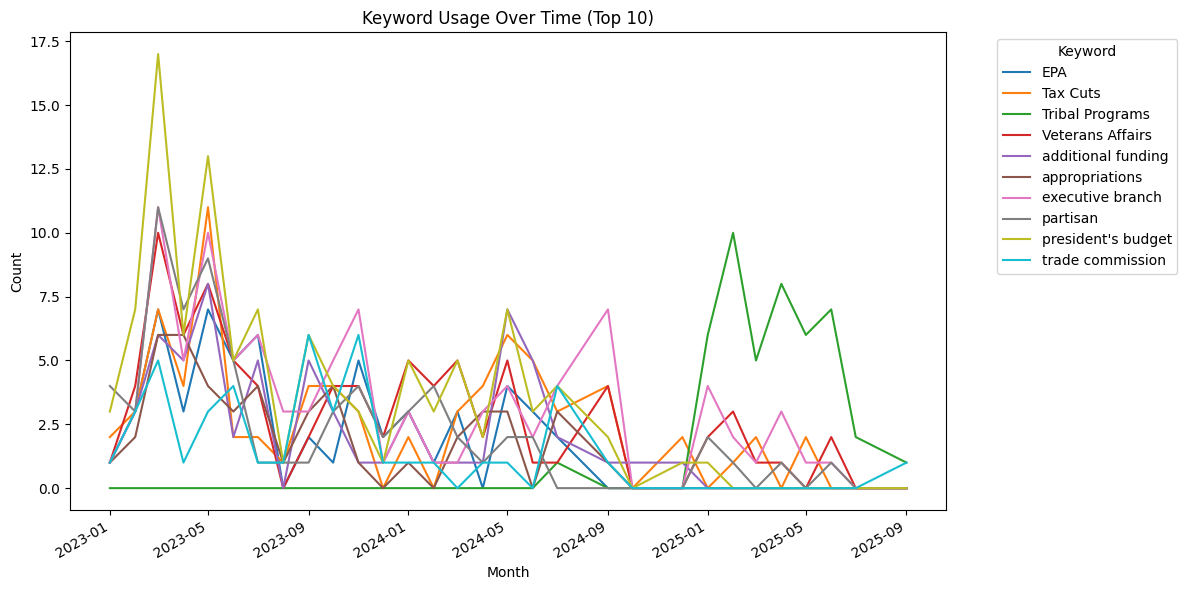

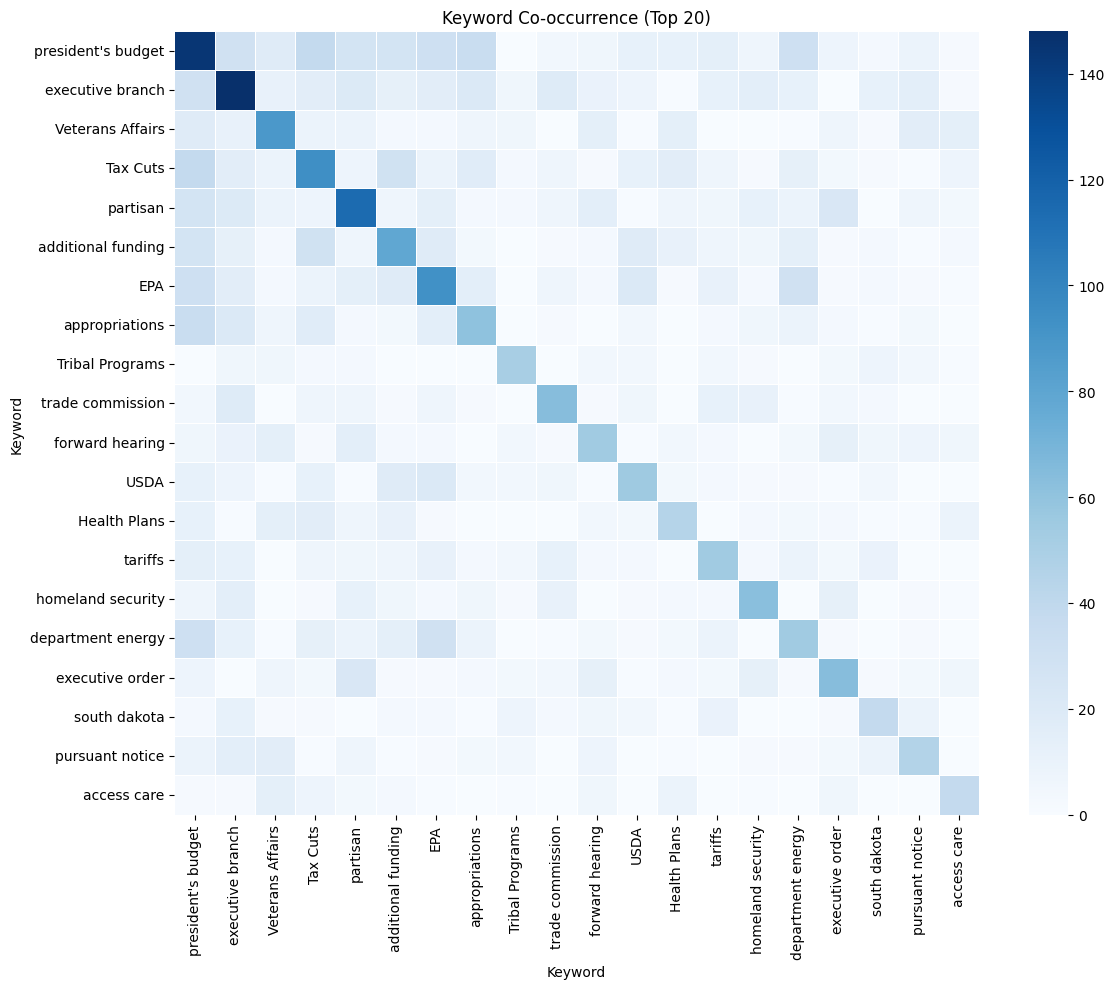

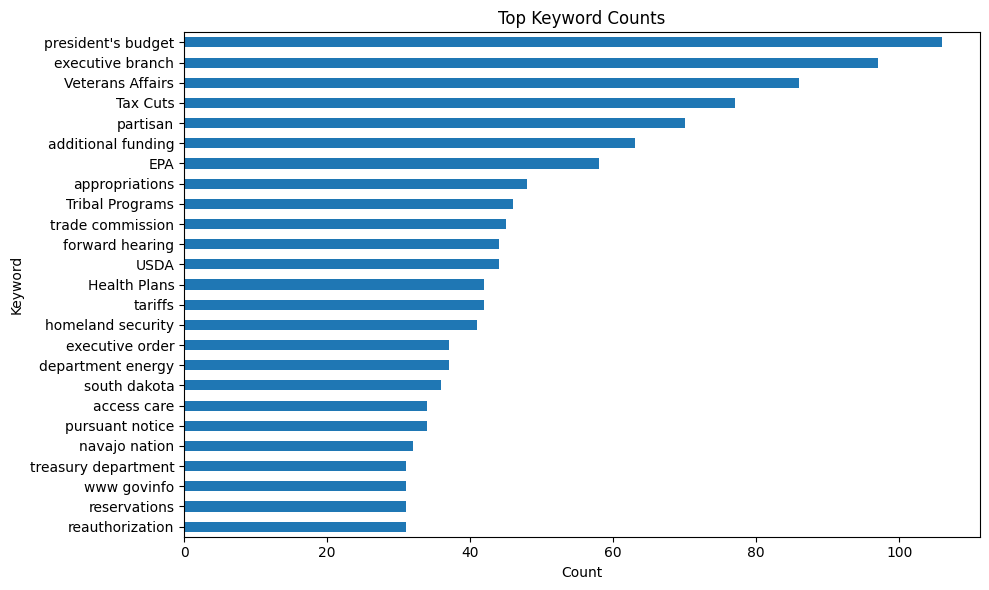

In [32]:
# Time trends, co-occurrences, and counts
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# Ensure date
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
else:
    raise ValueError("Expected 'date' column in dataframe")

# Use the same cleaning rules as earlier cell
banned_substrings = [
    'senate committee', 'house committee', 'committee hearing', 'hearing committee',
    'committee judiciary', 'committee finance', 'finance committee', 'committee health',
    'committee presiding', 'special committee', 'members subcommittee', 'members senate',
    'committee aging', 'use committee', 'committee thank', 'committees',
    'committee met', 'members committee', 'committee members', 'members congress', 'subcommittee', 'committee',
    'opening statement', 'testimony', 'testified', 'chairman', 'ranking member', 'senator',
    'representative', 'congressman', 'congresswoman', 'good morning', 'good afternoon',
    'thank you', 'distinguished', 'witness', 'panel', 'hearing adjourned', 'hearing today', 'today hearing',
    'chair durbin', 'questions chair', 'chief counsel',
    'senate', 'states senate', 'congress session', 'eighteenth congress', 'congress',
    '2023 senate', '2024 budget', 'senate office', 'senate eighteenth', 'hearings',
    'congressional', 'pdf washington', 'dc committee', 'act 2023', 'gov document', 'docs fcc', 'statement fcc',
    'board directors', 'briefing', 'justices', 'government publishing',
    'republican staff', 'chair warren', 'document fcc', 'filing', 'secretary state', 'judiciary', 'policymakers',
    'menendez', 'sanders', 'murkowski',
    'federal', 'bipartisan', 'administrations', 'assessed'
]

normalize_map = {
    'president budget': "president's budget",
    "president's budget": "president's budget",
    'presidents budget': "president's budget",
    'white house budget': "president's budget",
    'epa': 'EPA', 'fcc': 'FCC', 'federal reserve': 'Federal Reserve',
    'veterans affairs': 'Veterans Affairs', 'va': 'Veterans Affairs',
    'department of energy': 'DOE', 'doe': 'DOE',
    'department of transportation': 'DOT', 'dot': 'DOT',
    'department of defense': 'DoD', 'dod': 'DoD',
    'department of homeland security': 'Homeland Security', 'dhs': 'Homeland Security',
    'centers for disease control': 'CDC', 'cdc': 'CDC',
    'food and drug administration': 'FDA', 'fda': 'FDA',
    'department agriculture': 'USDA',
    'bipartisan infrastructure': 'Bipartisan Infrastructure',
    'bipartisan support': 'Bipartisan Support',
    'federal funding': 'Federal Funding', 'federal agencies': 'Federal Agencies',
    'natural gas': 'Natural Gas', 'health plans': 'Health Plans',
    'tax cuts': 'Tax Cuts', 'tribal programs': 'Tribal Programs',
}


def is_banned(k: str) -> bool:
    kl = k.lower()
    if kl.strip() == '':
        return True
    for sub in banned_substrings:
        if sub in kl:
            return True
    return False


def norm(k: str) -> str:
    kl = k.lower()
    return normalize_map.get(kl, k)

# Build cleaned keyword list per row
kw_cols = [c for c in df.columns if c.startswith('kw_')]
clean_kws = []
for _, row in df.iterrows():
    kws = []
    for c in kw_cols:
        v = row.get(c, '')
        if isinstance(v, str) and v.strip() != '' and not is_banned(v):
            kws.append(norm(v))
    clean_kws.append(kws)

df['clean_kws'] = clean_kws

# Limit time series to 2023 through today and drop missing dates
start_date = pd.Timestamp(2023, 1, 1)
end_date = pd.Timestamp.today().normalize()
df_time = df.dropna(subset=['date']).copy()
df_time = df_time[(df_time['date'] >= start_date) & (df_time['date'] <= end_date)]

# 1) Use over time: monthly counts for top keywords
month_col = df_time['date'].dt.to_period('M').dt.to_timestamp()
kw_exploded = (
    df_time.assign(month=month_col)
      .explode('clean_kws')
)
kw_exploded = kw_exploded[kw_exploded['clean_kws'].notna() & (kw_exploded['clean_kws'] != '')]

# Determine top N keywords overall
topN = 10
overall_counts = kw_exploded['clean_kws'].value_counts().head(topN).index.tolist()

trend = (kw_exploded[kw_exploded['clean_kws'].isin(overall_counts)]
         .groupby(['month','clean_kws']).size().reset_index(name='count'))
trend_pivot = trend.pivot(index='month', columns='clean_kws', values='count').fillna(0)

plt.figure(figsize=(12,6))
trend_pivot.plot(ax=plt.gca())
plt.title('Keyword Usage Over Time (Top {})'.format(topN))
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Keyword', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2) Co-occurrences heatmap (Top M keywords)
M = 20
topM = kw_exploded['clean_kws'].value_counts().head(M).index.tolist()
co_counts = {(a,b):0 for a in topM for b in topM}

for kws in df['clean_kws']:
    kws = [k for k in set(kws) if k in topM]
    for a, b in combinations(sorted(kws), 2):
        co_counts[(a,b)] += 1
        co_counts[(b,a)] += 1
    for k in kws:
        co_counts[(k,k)] += 1

# Build matrix
mat = pd.DataFrame(index=topM, columns=topM, data=0)
for (a,b), v in co_counts.items():
    mat.at[a,b] = v

plt.figure(figsize=(12,10))
sns.heatmap(mat, cmap='Blues', linewidths=.5)
plt.title('Keyword Co-occurrence (Top {})'.format(M))
plt.xlabel('Keyword')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

# 3) Counts
# 3a) Top keyword counts bar chart
topK = 25
kw_counts = kw_exploded['clean_kws'].value_counts().head(topK)
plt.figure(figsize=(10,6))
kw_counts.sort_values().plot(kind='barh')
plt.title('Top Keyword Counts')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

# 3b) Document word count (if text available)
if 'text' in df.columns:
    df['word_count'] = df['text'].fillna('').str.split().str.len()
    plt.figure(figsize=(10,5))
    df['word_count'].plot(kind='hist', bins=50)
    plt.title('Document Word Count Distribution')
    plt.xlabel('Words')
    plt.ylabel('Documents')
    plt.tight_layout()
    plt.show()


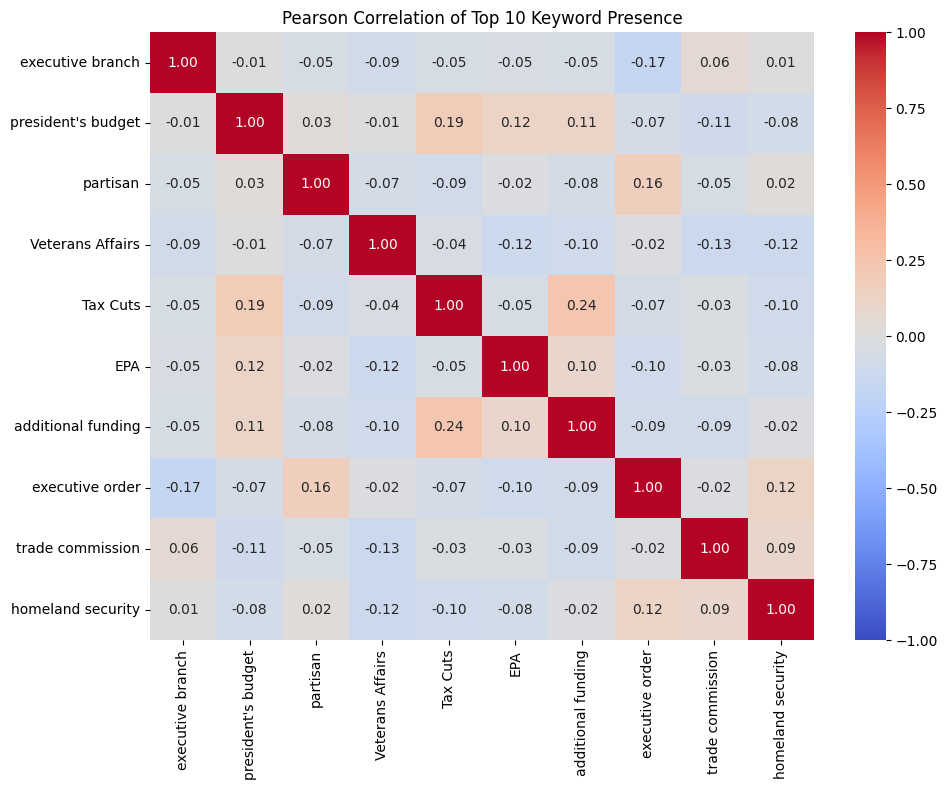

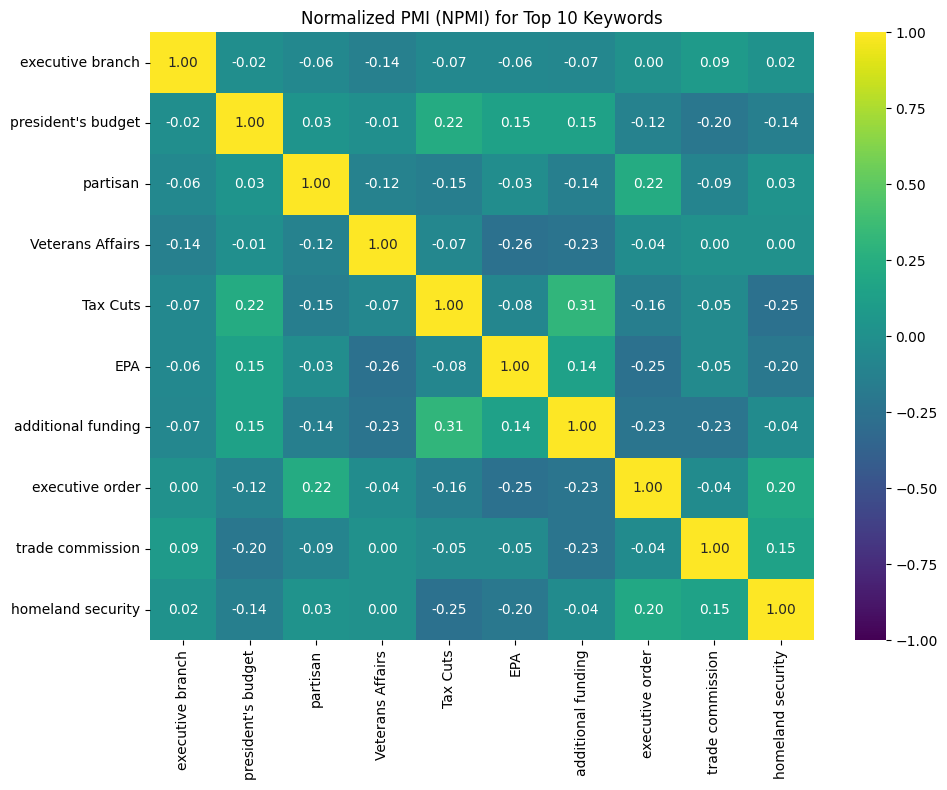

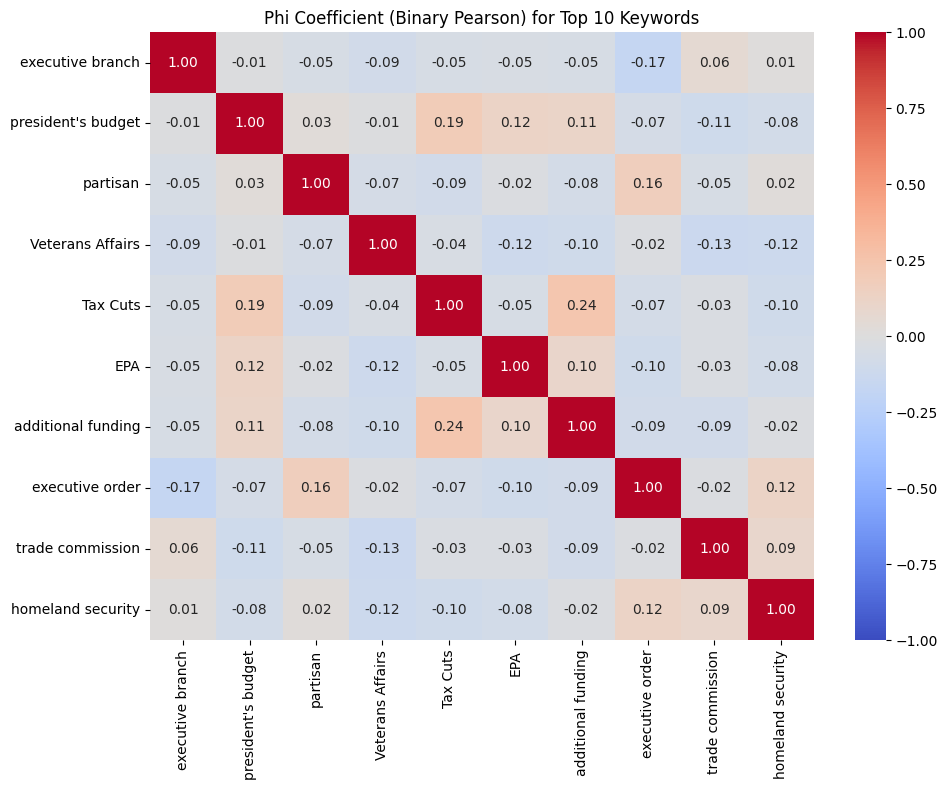

In [33]:
# Correlation and association of top 10 keywords
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes df and df['clean_kws'] already built above
# Re-derive top10 from earlier kw_exploded if available, else compute here
if 'clean_kws' not in df.columns:
    raise ValueError("Expected 'clean_kws' column built in prior cell.")

# Determine top 10 keywords overall across documents
all_kws = pd.Series([k for kws in df['clean_kws'] for k in kws])
top10 = all_kws.value_counts().head(10).index.tolist()

# Build binary presence DataFrame: rows=documents, cols=top10, value=1 if keyword present in doc
presence = pd.DataFrame({kw: df['clean_kws'].apply(lambda ks: int(kw in set(ks))) for kw in top10})

# 1) Pearson correlation between keyword presence vectors
corr = presence.corr(method='pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation of Top 10 Keyword Presence')
plt.tight_layout()
plt.show()

# 2) Normalized Pointwise Mutual Information (NPMI)
# Compute joint and marginal probabilities over documents
n_docs = len(presence)
p = presence.sum(axis=0) / n_docs
joint = (presence.T @ presence) / n_docs  # joint prob for pairs (includes diagonal)

def npmi(a, b):
    pab = joint.loc[a, b]
    pa = p[a]
    pb = p[b]
    if pab == 0 or pa == 0 or pb == 0:
        return 0.0
    pmi = np.log(pab / (pa * pb))
    return pmi / (-np.log(pab))

npmi_mat = pd.DataFrame(index=top10, columns=top10, dtype=float)
for a in top10:
    for b in top10:
        npmi_mat.loc[a, b] = npmi(a, b)

plt.figure(figsize=(10,8))
sns.heatmap(npmi_mat.astype(float), annot=True, fmt='.2f', cmap='viridis', vmin=-1, vmax=1)
plt.title('Normalized PMI (NPMI) for Top 10 Keywords')
plt.tight_layout()
plt.show()

# 3) Optional: Phi coefficient (equivalent to Pearson for binary) for confirmation
phi = corr.copy()  # same as Pearson on binary indicators
plt.figure(figsize=(10,8))
sns.heatmap(phi, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Phi Coefficient (Binary Pearson) for Top 10 Keywords')
plt.tight_layout()
plt.show()

### Top Keyword Pairs (NPMI vs Pearson)
These tables list the strongest keyword pairs among the current top-10:
- NPMI: highlights pairs that co-occur more than expected by chance.
- Pearson: measures linear correlation of binary presence across documents.
Pairs are ordered descending by strength and exclude self-pairs.

In [34]:
# Build top pairs (exclude self-pairs) from prior matrices
import pandas as pd

# Ensure previous variables exist
if 'npmi_mat' not in globals() or 'corr' not in globals() or 'top10' not in globals():
    raise ValueError("Expected npmi_mat, corr, and top10 from previous cell.")

def upper_triangle_pairs(mat_df):
    pairs = []
    for i, a in enumerate(mat_df.index):
        for j, b in enumerate(mat_df.columns):
            if j <= i:
                continue
            val = float(mat_df.loc[a, b])
            pairs.append((a, b, val))
    return pairs

# Top by NPMI
npmi_pairs = upper_triangle_pairs(npmi_mat)
npmi_top = sorted(npmi_pairs, key=lambda x: x[2], reverse=True)
npmi_top_df = pd.DataFrame(npmi_top, columns=['keyword_a','keyword_b','npmi']).head(15)
display(npmi_top_df)

# Top by Pearson correlation
corr_pairs = upper_triangle_pairs(corr)
corr_top = sorted(corr_pairs, key=lambda x: x[2], reverse=True)
corr_top_df = pd.DataFrame(corr_top, columns=['keyword_a','keyword_b','pearson']).head(15)
display(corr_top_df)

,keyword_a,keyword_b,npmi
0,Tax Cuts,additional funding,0.308281
1,partisan,executive order,0.223802
2,president's budget,Tax Cuts,0.222563
3,executive order,homeland security,0.197185
4,trade commission,homeland security,0.148622
5,president's budget,additional funding,0.146806
6,president's budget,EPA,0.145275
7,EPA,additional funding,0.139146
8,executive branch,trade commission,0.085263
9,president's budget,partisan,0.032921


,keyword_a,keyword_b,pearson
0,Tax Cuts,additional funding,0.239745
1,president's budget,Tax Cuts,0.187709
2,partisan,executive order,0.164730
3,executive order,homeland security,0.122286
4,president's budget,EPA,0.117365
5,president's budget,additional funding,0.114393
6,EPA,additional funding,0.095337
7,trade commission,homeland security,0.087523
8,executive branch,trade commission,0.060950
9,president's budget,partisan,0.026207
